In [147]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [148]:
import pandas as pd
import numpy as np

#trainData = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
trainData = pd.read_csv("train.csv")
trainData.head(100)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,0,3,"Shorney, Mr. Charles Joseph",male,NaN,0,0,374910,8.0500,NaN,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
97,98,1,1,"Greenfield, Mr. William Bertram",male,23.0,0,1,PC 17759,63.3583,D10 D12,C
98,99,1,2,"Doling, Mrs. John T (Ada Julia Bone)",female,34.0,0,1,231919,23.0000,NaN,S


In [149]:
#testData = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")
testData = pd.read_csv("test.csv")
testData.head()


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


# Data visualisation

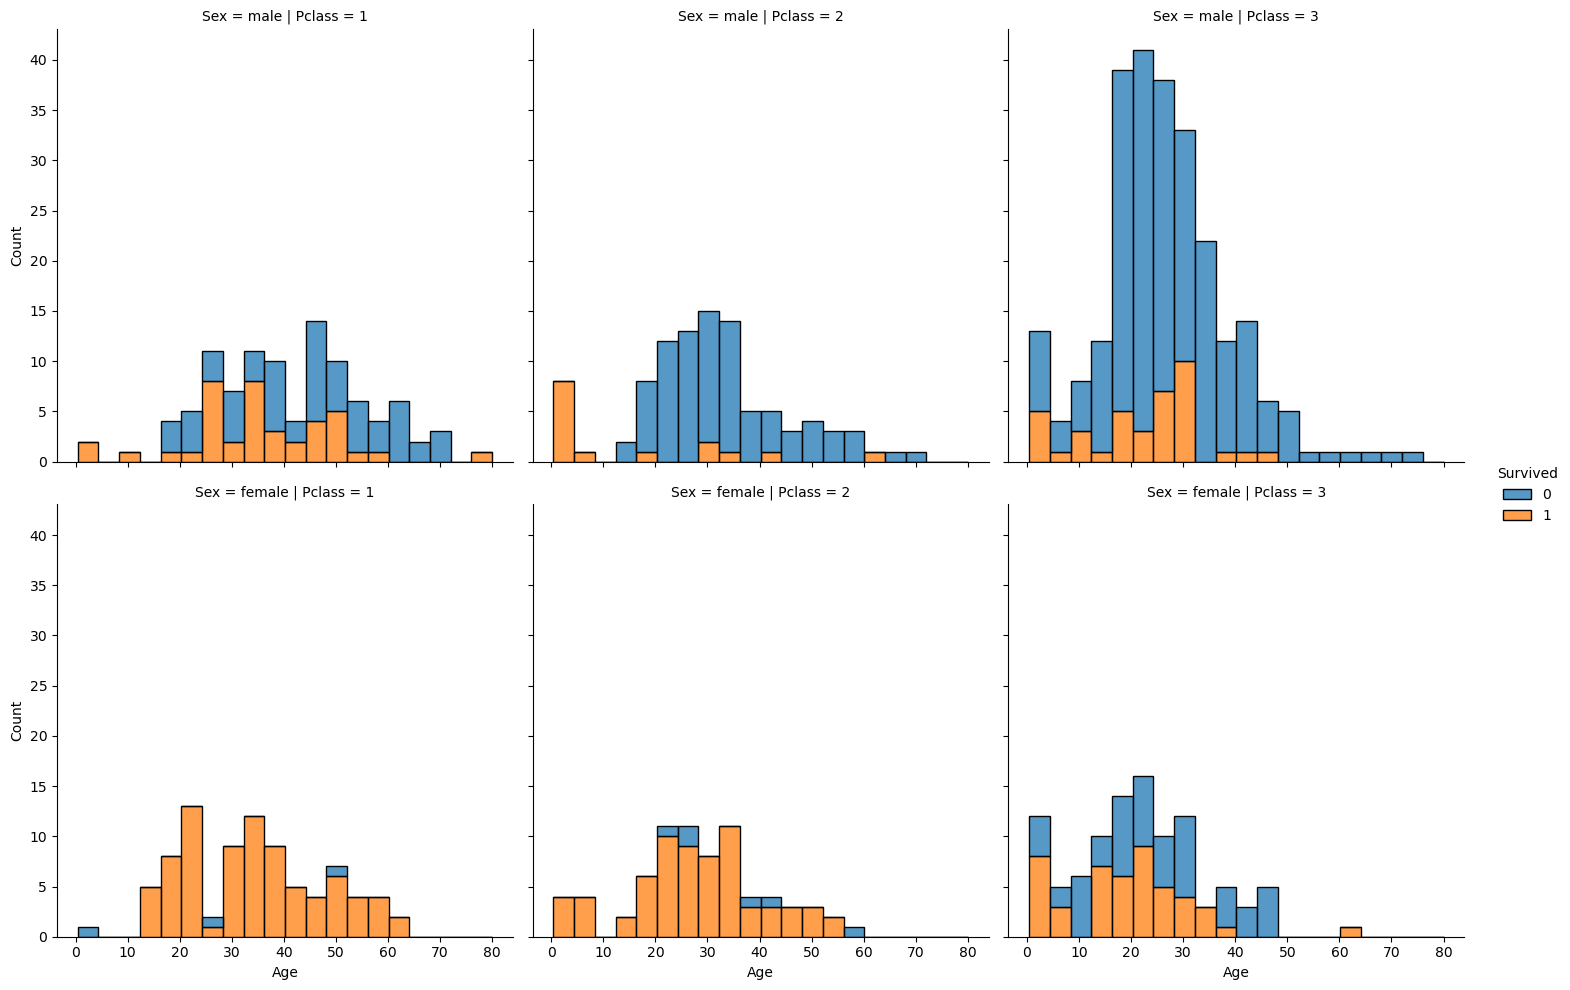

In [150]:
import seaborn as sns

sns.displot(data=trainData,x="Age", hue="Survived", multiple="stack", col="Pclass",row="Sex")

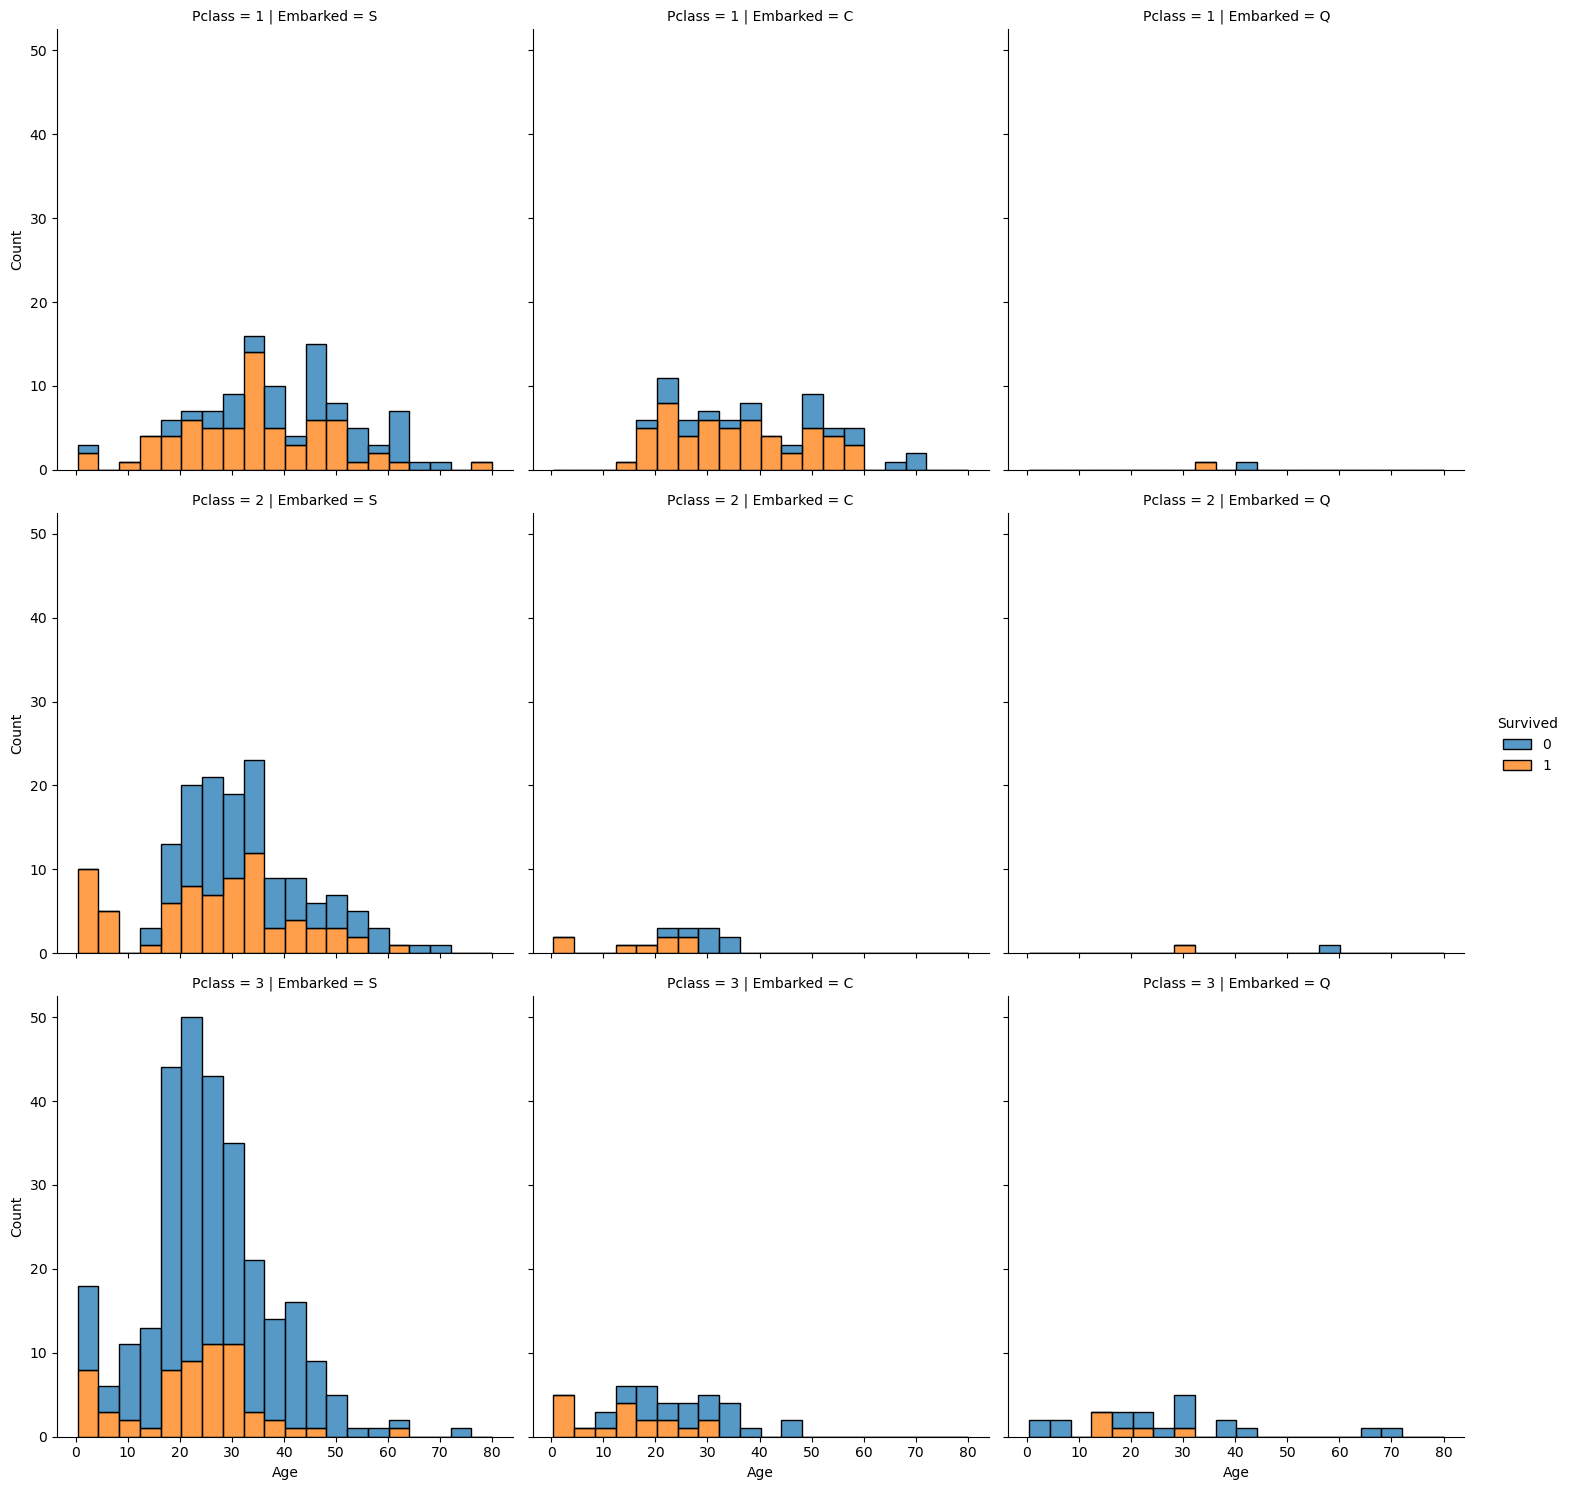

In [151]:
sns.displot(data=trainData,x="Age", hue="Survived", multiple="stack", col="Embarked",row="Pclass")

<Axes: xlabel='Pclass', ylabel='Fare'>

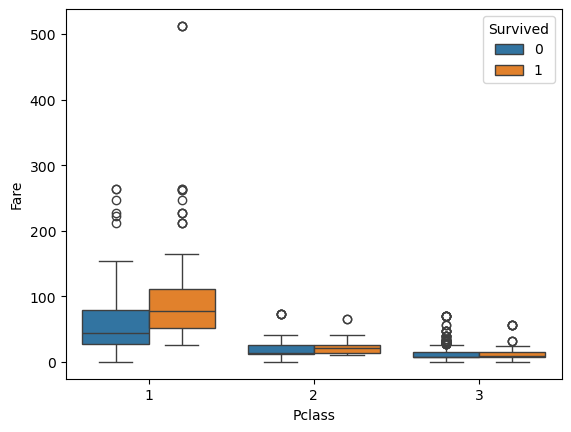

In [152]:
sns.boxplot(data=trainData, x="Pclass", y="Fare", hue="Survived")

Feature ENGINEERING

In [153]:
print(trainData.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [154]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OneHotEncoder, KBinsDiscretizer
from sklearn.svm import SVC # type: ignore
from sklearn.ensemble import RandomForestClassifier # type: ignore

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

def checkCabin(df):
    return df.notnull().astype(int)

def getCabinNames(transformer, input_features):
    return ["hasCabin"]

def calculateFamilySize(df):
    family_size = df.iloc[:,0] + df.iloc[:,1]
    return family_size.values.reshape(-1, 1)

def getFamilySizeNames(transformer, input_features):
    return ["FamilySize"]

def extractStatus(df):
    titles = df.iloc[:, 0].str.extract(' ([A-Za-z]+)\.', expand=False)
    
    # Optional: Group rare titles into 'Other' to avoid noise
    # This prevents the model from overfitting on a single "Countess"
    titles = titles.replace(['Lady', 'Count', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 
                             'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    titles = titles.replace('Mlle', 'Miss')
    titles = titles.replace('Ms', 'Miss')
    titles = titles.replace('Mme', 'Mrs')
    
    return titles.values.reshape(-1, 1)

def getStatusNames(transformer, input_features):
    return ["Title"]


interaction_transformer = FunctionTransformer(createInteractions, feature_names_out=getInteractionNames, validate=False)

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

cabin_Transformer = FunctionTransformer(checkCabin, feature_names_out=getCabinNames, validate=False)

fare_Transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('discretizer', KBinsDiscretizer(n_bins=3, encode='onehot-dense', strategy='quantile', quantile_method='averaged_inverted_cdf'))
    ])

family_Transformer = Pipeline(steps=[    
    ('transformer', FunctionTransformer(calculateFamilySize, feature_names_out=getFamilySizeNames, validate=False)),
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

status_Transformer = Pipeline(steps=[
    ('extractor', FunctionTransformer(extractStatus, feature_names_out=getStatusNames, validate=False)),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, ['Age']),
        ('cat', cat_transformer, ['Sex', 'Embarked', 'Pclass']),
        ('cabin', cabin_Transformer, ['Cabin']),
        ('fare', fare_Transformer, ['Fare']),
        ('family', family_Transformer, ['SibSp', 'Parch']),
        ('status', status_Transformer, ['Name'])
    ])

clf_svm = Pipeline(steps = [("preprocessor", preprocessor),
                            ("model", SVC())
                            ])

clf_rf = Pipeline(steps = [("preprocessor", preprocessor),
                            ("model", RandomForestClassifier( n_estimators=100, random_state=42))
                            ])


y = trainData["Survived"]
X = trainData.drop(columns=["Survived"])

Check preprocessing

In [155]:
preprocessed_data = clf_svm.named_steps['preprocessor'].fit_transform(X)
# Get the column names created by the transformers (One-Hot, etc.)
column_names = clf_svm.named_steps['preprocessor'].get_feature_names_out()

# Create a readable DataFrame
check_df = pd.DataFrame(preprocessed_data, columns=column_names)

# View the first few rows
print(check_df.head())

   num__Age  cat__Sex_female  cat__Sex_male  cat__Embarked_C  cat__Embarked_Q  \
0 -0.565736              0.0            1.0              0.0              0.0   
1  0.663861              1.0            0.0              1.0              0.0   
2 -0.258337              1.0            0.0              0.0              0.0   
3  0.433312              1.0            0.0              0.0              0.0   
4  0.433312              0.0            1.0              0.0              0.0   

   cat__Embarked_S  cat__Embarked_missing  cat__Pclass_1  cat__Pclass_2  \
0              1.0                    0.0            0.0            0.0   
1              0.0                    0.0            1.0            0.0   
2              1.0                    0.0            0.0            0.0   
3              1.0                    0.0            1.0            0.0   
4              1.0                    0.0            0.0            0.0   

   cat__Pclass_3  cabin__hasCabin  fare__Fare_0.0  fare__Fare_

Grid Search for the SVM

In [156]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__C': [5, 10, 20],
    'model__gamma': [0.01, 0.03, 0.1],
    'model__kernel': ['rbf', 'poly']
}

grid_search = GridSearchCV(clf_svm, param_grid, cv=5, scoring='f1')
grid_search.fit(X, y)
print(f"Best Parameters: {grid_search.best_params_}")

best_svm = grid_search.best_estimator_

Best Parameters: {'model__C': 10, 'model__gamma': 0.03, 'model__kernel': 'rbf'}


Plot confusion matrices and compare

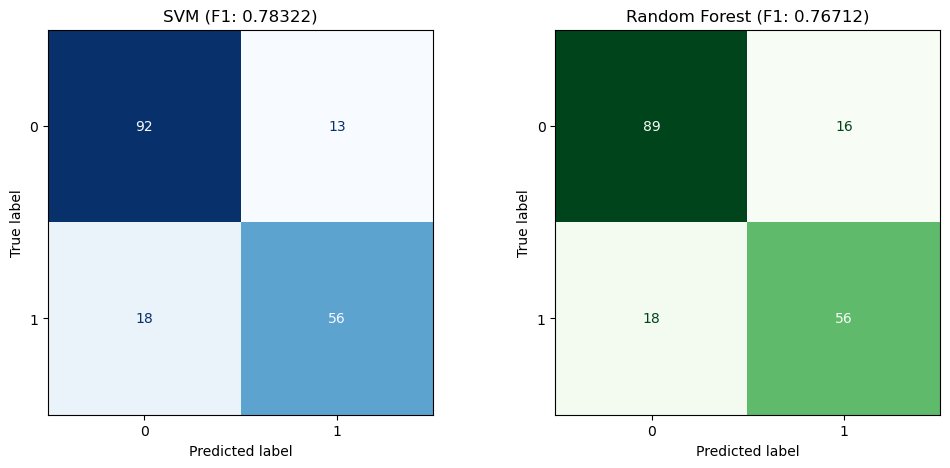

In [157]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt

X_train_sub, X_val, y_train_sub, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


best_svm.fit(X_train_sub, y_train_sub)
clf_rf.fit(X_train_sub, y_train_sub)

y_pred = best_svm.predict(X_val)
y_pred_rf = clf_rf.predict(X_val)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot SVM
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, ax=ax[0], cmap='Blues', colorbar=False)
ax[0].set_title(f"SVM (F1: {f1_score(y_val, y_pred):.5f})")

# Plot Random Forest
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_rf, ax=ax[1], cmap='Greens', colorbar=False)
ax[1].set_title(f"Random Forest (F1: {f1_score(y_val, y_pred_rf):.5f})")

plt.show()


Error analysis

In [158]:
mismatched_mask = (y_val != y_pred)

errors_df = X_val.iloc[mismatched_mask.values].copy()

errors_df['Actual'] = y_val.values[mismatched_mask]
errors_df['Predicted'] = y_pred[mismatched_mask]

false_positives = errors_df[errors_df['Predicted'] == 1]
print(false_positives.head(10))

     PassengerId  Pclass                                           Name  \
396          397       3                            Olsson, Miss. Elina   
235          236       3                   Harknett, Miss. Alice Phoebe   
362          363       3                Barbara, Mrs. (Catherine David)   
772          773       2                              Mack, Mrs. (Mary)   
312          313       2          Lahtinen, Mrs. William (Anna Sylfven)   
767          768       3                             Mangan, Miss. Mary   
357          358       2                      Funk, Miss. Annie Clemmer   
254          255       3       Rosblom, Mrs. Viktor (Helena Wilhelmina)   
578          579       3               Caram, Mrs. Joseph (Maria Elias)   
49            50       3  Arnold-Franchi, Mrs. Josef (Josefine Franchi)   

        Sex   Age  SibSp  Parch       Ticket     Fare Cabin Embarked  Actual  \
396  female  31.0      0      0       350407   7.8542   NaN        S       0   
235  female   

In [159]:
false_negatives = errors_df[errors_df['Predicted'] == 0]
print(false_negatives.head(10))

     PassengerId  Pclass                          Name   Sex   Age  SibSp  \
621          622       1  Kimball, Mr. Edwin Nelson Jr  male  42.0      1   
447          448       1   Seward, Mr. Frederic Kimber  male  34.0      0   
673          674       2         Wilhelms, Mr. Charles  male  31.0      0   
204          205       3      Cohen, Mr. Gurshon "Gus"  male  18.0      0   
23            24       1  Sloper, Mr. William Thompson  male  28.0      0   
889          890       1         Behr, Mr. Karl Howell  male  26.0      0   
712          713       1      Taylor, Mr. Elmer Zebley  male  48.0      1   
338          339       3         Dahl, Mr. Karl Edwart  male  45.0      0   
286          287       3       de Mulder, Mr. Theodore  male  30.0      0   
209          210       1              Blank, Mr. Henry  male  40.0      0   

     Parch    Ticket     Fare Cabin Embarked  Actual  Predicted  
621      0     11753  52.5542   D19        S       1          0  
447      0    113794

Generate predictions on Final test SET

In [160]:
# Train on the FULL training set before final submission
best_svm.fit(X, y)

# Predict on the competition test data
test_preds = best_svm.predict(testData)

# Create the submission dataframe
submission = pd.DataFrame({
    "PassengerId": testData["PassengerId"],
    "Survived": test_preds
})

# Save to CSV
submission.to_csv('submission.csv', index=False)